# Compare AIC across best-fit files

In [11]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import sys
sys.path.append("../src")

from Config.config import PATHS

In [12]:
def load_aic(path: Path) -> pd.Series:
    df = pd.read_json(path, lines=True)
    return df.set_index('model_name')['AIC']


mle_dir = PATHS['parameter_fit_results']
aic_full = load_aic(mle_dir / 'best_fit.json')
aic_generic = load_aic(mle_dir / 'best_fit_generic.json')
aic_small = load_aic(mle_dir / 'best_fit_small.json')

aic_generic = aic_generic[aic_generic.index.str.contains('ICSM')]

table = pd.concat(
    {
        'AIC': aic_full,
        'No empirical bias': aic_generic,
        'Small': aic_small,
    },
    axis=1,
)
table.index.name = 'Model'
table = table.sort_values(by=['AIC', 'Small'], na_position='last')
table

,AIC,No empirical bias,Small
Model,,,
Attendance+Payoff+ICSM-M1,38102.009503,40644.398847,15740.612799
Attendance-M1,39866.167666,NaN,17504.438080
OnlyAttendance-M1,40236.195069,NaN,17738.426815
Fairness+Payoff+ICSM-M1,41334.010929,41514.324573,16676.620985
Payoff+ICSM-M1,41364.448254,40755.423794,16676.899195
ICSM,41408.534184,41601.199722,16664.620985
Payoff-M1,42909.928286,NaN,18566.233578
Fairness-M1,42919.207206,NaN,18593.433723
OnlyFairness-M1,44315.967781,NaN,18863.603311


Saved /Users/edgarjoseandradelotero/GitHub/Cognitive_Models_El_Farol_Bar_Problem/images/exploratory/aic_comparison.png


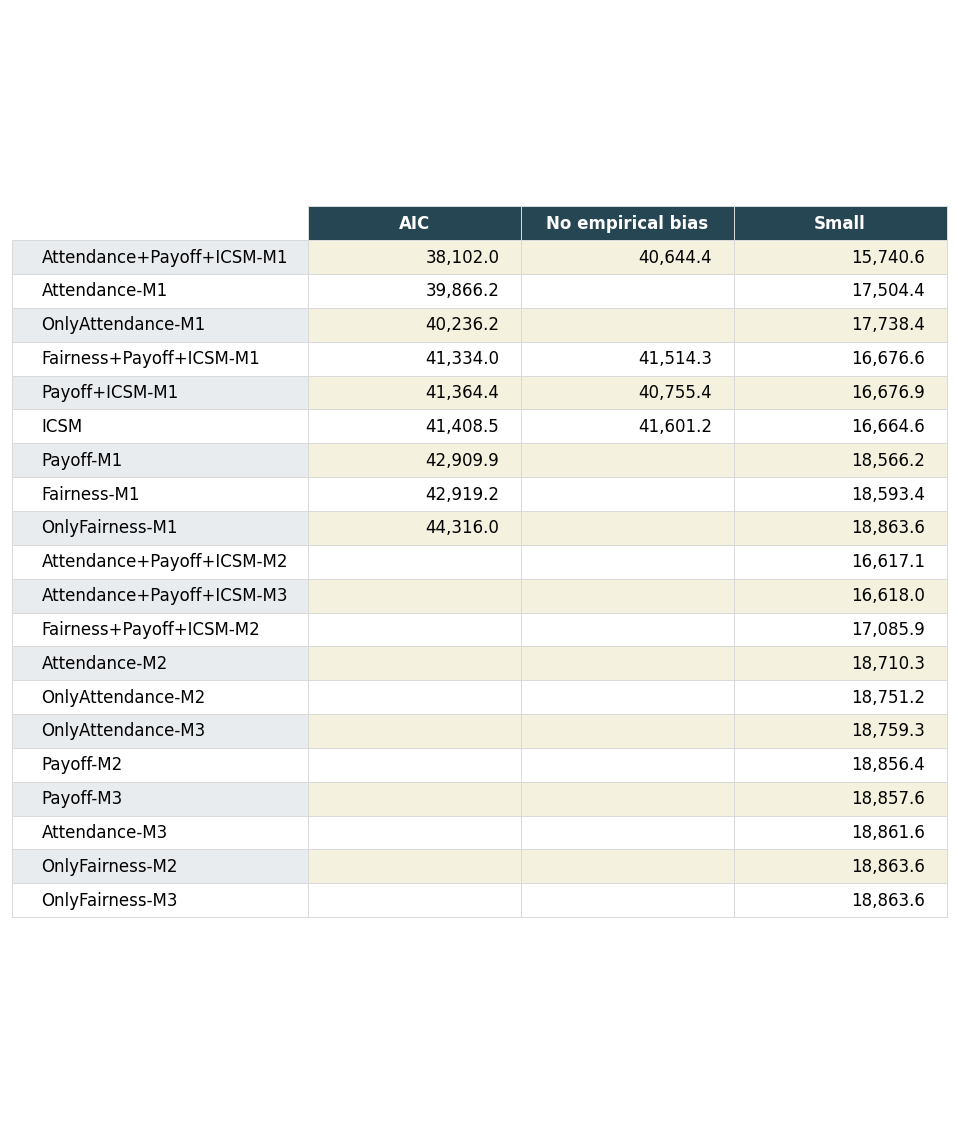

In [13]:
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'figure.dpi': 120,
})

display = table.copy()
cell_text = []
for _, row in display.iterrows():
    cell_text.append([
        '' if pd.isna(v) else f'{v:,.1f}'
        for v in row
    ])

n_rows = len(display)
fig, ax = plt.subplots(figsize=(8.4, 0.42 * n_rows + 1.1))
ax.axis('off')
tbl = ax.table(
    cellText=cell_text,
    rowLabels=list(display.index),
    colLabels=list(display.columns),
    loc='center',
    cellLoc='right',
    rowLoc='left',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.15, 1.35)

header_color = '#264653'
stripe = '#f4f1de'
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#d9d9d9')
    cell.set_linewidth(0.6)
    if r == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color='white', weight='bold', ha='center')
    elif c == -1:
        cell.set_facecolor('#e9ecef' if r % 2 else 'white')
        cell.set_text_props(ha='left', weight='medium')
    else:
        cell.set_facecolor(stripe if r % 2 else 'white')

fig.tight_layout()
out = PATHS['exploratory_figures'] / 'aic_comparison.png'
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=300, bbox_inches='tight')
print('Saved', out)

In [14]:
latex = table.to_latex(
    na_rep='---',
    float_format=lambda x: f'{x:,.1f}',
    column_format='lrrr',
    caption='AIC by model for the full sample, fits without empirical focal schemata, and the small-group sample.',
    label='tab:aic-comparison',
    escape=True,
)
print(latex)

\begin{table}
\caption{AIC by model for the full sample, fits without empirical focal schemata, and the small-group sample.}
\label{tab:aic-comparison}
\begin{tabular}{lrrr}
\toprule
 & AIC & No empirical bias & Small \\
Model &  &  &  \\
\midrule
Attendance+Payoff+ICSM-M1 & 38,102.0 & 40,644.4 & 15,740.6 \\
Attendance-M1 & 39,866.2 & --- & 17,504.4 \\
OnlyAttendance-M1 & 40,236.2 & --- & 17,738.4 \\
Fairness+Payoff+ICSM-M1 & 41,334.0 & 41,514.3 & 16,676.6 \\
Payoff+ICSM-M1 & 41,364.4 & 40,755.4 & 16,676.9 \\
ICSM & 41,408.5 & 41,601.2 & 16,664.6 \\
Payoff-M1 & 42,909.9 & --- & 18,566.2 \\
Fairness-M1 & 42,919.2 & --- & 18,593.4 \\
OnlyFairness-M1 & 44,316.0 & --- & 18,863.6 \\
Attendance+Payoff+ICSM-M2 & --- & --- & 16,617.1 \\
Attendance+Payoff+ICSM-M3 & --- & --- & 16,618.0 \\
Fairness+Payoff+ICSM-M2 & --- & --- & 17,085.9 \\
Attendance-M2 & --- & --- & 18,710.3 \\
OnlyAttendance-M2 & --- & --- & 18,751.2 \\
OnlyAttendance-M3 & --- & --- & 18,759.3 \\
Payoff-M2 & --- & --- & 18,856.